## Configuración inicial y autenticación con BigQuery

Se importan las librerías necesarias de Google Cloud y se establece el identificador del proyecto. También se utiliza la autenticación predeterminada de gcloud para acceder a BigQuery.

In [4]:
from google.cloud import bigquery

PROJECT_ID = "project3grupo1"

# Usa Application Default Credentials (gcloud auth application-default login)
client = bigquery.Client(project=PROJECT_ID)
print("✅ Conectado a BigQuery con Application Default Credentials")

datasets = list(client.list_datasets())
for ds in datasets:
    print(ds.dataset_id)


c:\Users\sescorue\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\auth\_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


✅ Conectado a BigQuery con Application Default Credentials
airbnb_features
airbnb_raw
dbt_transform
airbnb_features
airbnb_raw
dbt_transform


## Definición de la consulta SQL

Se define una cadena que contiene la consulta SQL para extraer todos los registros de la tabla de características de ocupación (mart_occupancy_features).

In [5]:
query = """
SELECT *
FROM `project3grupo1.dbt_transform.mart_occupancy_features`
"""

df_final = client.query(query).to_dataframe()
df_final.head()
df_final.columns

Index(['is_occupied', 'date', 'day_of_week', 'month', 'year', 'is_weekend',
       'days_to_next_holiday', 'listing_id', 'neighbourhood_cleansed',
       'room_type', 'accommodates', 'bedrooms', 'beds', 'listing_price',
       'minimum_nights', 'number_of_reviews', 'review_scores_rating',
       'review_scores_cleanliness', 'review_scores_location',
       'review_scores_value', 'instant_bookable', 'latitude', 'longitude',
       'temp_max', 'temp_min', 'temp_mean', 'precipitation_mm', 'num_events',
       'num_concerts', 'num_sports', 'num_festivals', 'max_attendance',
       'total_attendance', 'is_holiday'],
      dtype='object')

## Exploración preliminar de ocupación y características

Se importan bibliotecas y se realizan cálculos exploratorios sobre el dataframe `df_final`: distribución de `is_occupied`, ocupación media por tipo de habitación (`room_type`) y por capacidad (`accommodates`). Esto permite identificar tendencias iniciales en la ocupación.

In [6]:
import pandas as pd

df_final['is_occupied'].value_counts(normalize=True)
df_final.groupby('room_type')['is_occupied'].mean()
df_final.groupby('accommodates')['is_occupied'].mean()
df_final.groupby('bedrooms')['is_occupied'].mean()
df_final[['review_scores_rating', 'is_occupied']].corr()
df_final.groupby(pd.qcut(df_final['review_scores_rating'], 5))['is_occupied'].mean()


C:\Users\sescorue\AppData\Local\Temp\ipykernel_10364\2335005818.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_final.groupby(pd.qcut(df_final['review_scores_rating'], 5))['is_occupied'].mean()


review_scores_rating
(0.999, 4.45]    0.351845
(4.45, 4.65]     0.357789
(4.65, 4.79]     0.379435
(4.79, 4.94]      0.40781
(4.94, 5.0]      0.392688
Name: is_occupied, dtype: Float64

## Análisis de correlaciones

Se importan las bibliotecas `seaborn` y `matplotlib` y se representa en un mapa de calor la matriz de correlaciones entre las variables numéricas del conjunto. Esto ayuda a identificar relaciones lineales entre variables.

<Axes: >

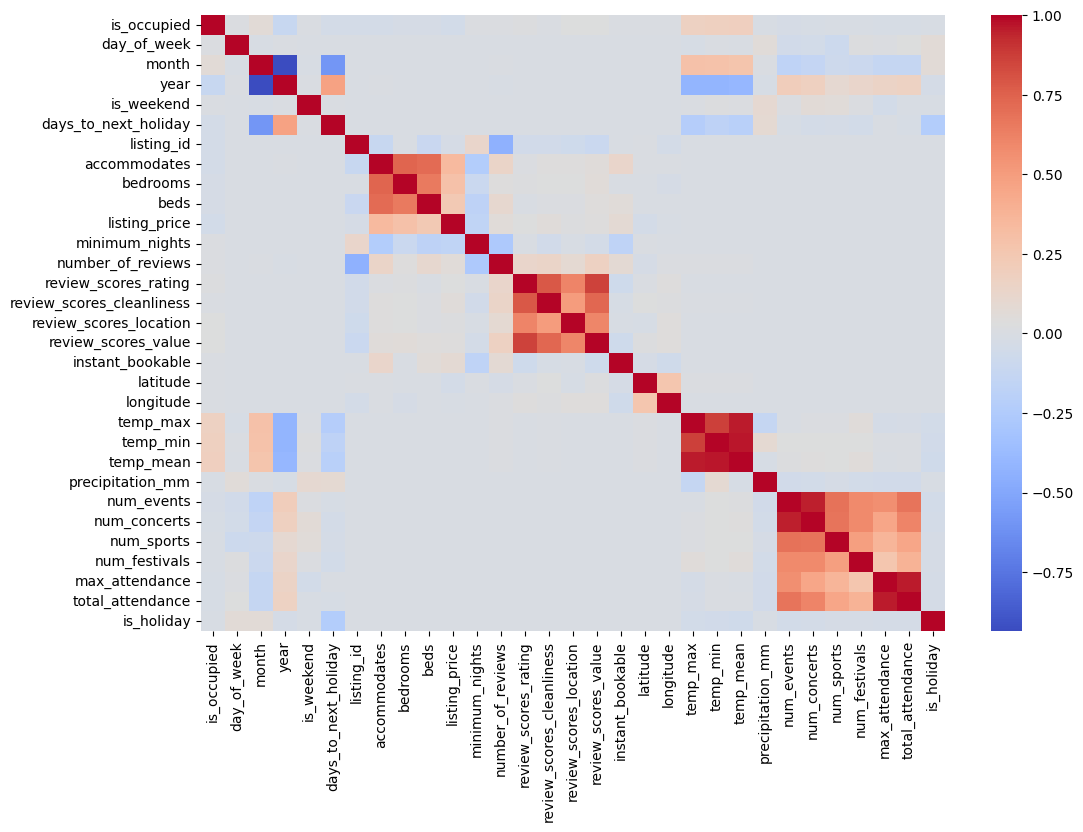

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df_final.corr(numeric_only=True), cmap='coolwarm')

## Distribución y valores nulos de `is_occupied`

Se analizan los valores de la variable `is_occupied`: conteo absoluto, conteo normalizado, número de valores nulos y el tamaño total del conjunto de datos.

In [8]:
df_final["is_occupied"].value_counts()
df_final["is_occupied"].value_counts(normalize=True)

df_final["is_occupied"].isna().sum()
len(df_final)

4287292

## Distribución de `is_occupied` incluyendo valores nulos

Se examina la distribución de `is_occupied` sin eliminar valores nulos mediante `value_counts(dropna=False)`.

In [9]:
df_final["is_occupied"].value_counts(dropna=False)

is_occupied
0    2711707
1    1575585
Name: count, dtype: Int64

## Proporción de ocupación y desocupación

Se calcula la proporción de los valores de `is_occupied` con respecto al total de registros para entender el desbalance de clases.

In [10]:
df_final["is_occupied"].value_counts(normalize=True)

is_occupied
0    0.632499
1    0.367501
Name: proportion, dtype: Float64

## Registros por alojamiento (`listing_id`)

Se agrupan los datos por `is_occupied` y se cuenta el número de registros por alojamiento para comprobar la presencia de duplicados y la distribución de observaciones por `listing_id`.

In [11]:
df_final.groupby("is_occupied")["listing_id"].count()

is_occupied
0    2711707
1    1575585
Name: listing_id, dtype: Int64

## Definición de nombres de día

Se crea un diccionario que asigna cada número de día de la semana a su nombre correspondiente (lunes a domingo). Esto se utilizará para sustituir valores numéricos por nombres legibles.

In [12]:
mapping = {
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday",
    7: "Sunday"
}
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

df_final["day_name"] = df_final["day_of_week"].map(mapping)
df_final.groupby("day_name")["is_occupied"].mean().sort_values()
df_final.groupby("day_name")["is_occupied"].mean().reindex(order)


day_name
Monday       0.362971
Tuesday      0.365121
Wednesday    0.362282
Thursday     0.362727
Friday       0.367623
Saturday     0.375652
Sunday       0.376331
Name: is_occupied, dtype: Float64

## Ocupación media por día de la semana

Se agrupan los datos por nombre del día (`day_name`) y se calcula la ocupación media. A continuación, se grafica la ocupación media por día para analizar patrones semanales.

<Axes: xlabel='day_name'>

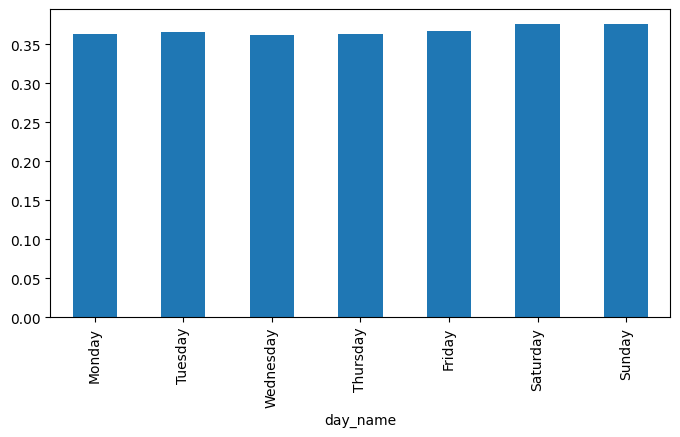

In [13]:
df_final.groupby("day_name")["is_occupied"].mean().reindex(
    ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
).plot(kind="bar", figsize=(8,4))

## Ocupación media por mes

Se calcula la ocupación media de `is_occupied` para cada mes y se ordena por índice para facilitar el análisis temporal.

In [14]:
df_final.groupby("month")["is_occupied"].mean()
ocupacion_mes = df_final.groupby("month")["is_occupied"].mean().sort_index()
ocupacion_mes


month
1     0.293705
2     0.293624
3     0.311882
4     0.335067
5      0.35887
6     0.752674
7     0.592217
8     0.411018
9     0.591927
10    0.511992
11    0.325668
12    0.262679
Name: is_occupied, dtype: Float64

## Visualización de la ocupación por mes

Se grafica la ocupación media por mes usando un gráfico de líneas para mostrar la estacionalidad a lo largo del año.

<Axes: xlabel='month'>

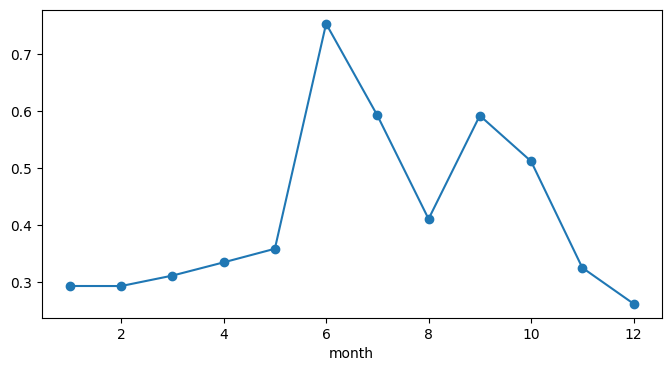

In [15]:
ocupacion_mes.plot(marker="o", figsize=(8,4))

## Análisis del mes de junio

Se evalúa el número de registros y el número de días únicos presentes en el dataset para el mes 6 (junio), con el fin de detectar posibles sesgos debidos a datos incompletos.

In [16]:
df_final[df_final["month"] == 6].shape
df_final[df_final["month"] == 6]["date"].nunique()

8

## Estadísticas agregadas por mes

Se calcula un conjunto de estadísticas para cada mes: ocupación media (`ocupacion_media`), total de registros, número de días únicos (`dias_unicos`) y porcentaje de datos (`pct_datos`). Esto permite evaluar la calidad y representatividad de los datos por mes.

In [18]:
total_rows = len(df_final)

ocupacion_mes = df_final.groupby("month").agg(
    ocupacion_media=("is_occupied", "mean"),
    total_registros=("is_occupied", "count"),
    dias_unicos=("date", "nunique")
)

ocupacion_mes["pct_datos"] = ocupacion_mes["total_registros"] / total_rows * 100

ocupacion_mes.sort_index()

,ocupacion_media,total_registros,dias_unicos,pct_datos
month,,,,
1,0.293705,509051,31,11.873486
2,0.293624,459788,28,10.724439
3,0.311882,509051,31,11.873486
4,0.335067,492630,30,11.49047
5,0.35887,197052,12,4.596188
6,0.752674,27951,8,0.65195
7,0.592217,128588,31,2.999283
8,0.411018,128588,31,2.999283
9,0.591927,323861,30,7.553976


## Filtrado de meses representativos

Se seleccionan los meses que tienen un porcentaje de datos superior al umbral establecido (>5%) para centrarse únicamente en periodos con suficientes observaciones.

In [19]:
meses_validos = ocupacion_mes[ocupacion_mes["pct_datos"] > 5].index

df_filtrado = df_final[df_final["month"].isin(meses_validos)]

## Clasificación de meses en estaciones del año

Se define una función que asigna cada mes a su estación (invierno, primavera, verano u otoño) y se aplica al conjunto de datos filtrado para realizar análisis estacional.

In [20]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df_filtrado["season"] = df_filtrado["month"].apply(get_season)

C:\Users\sescorue\AppData\Local\Temp\ipykernel_10364\1034314905.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado["season"] = df_filtrado["month"].apply(get_season)


## Ocupación media por estación

Se calculan y se ordenan las ocupaciones medias por estación del año para identificar la temporada con mayor y menor demanda.

In [ ]:
df_filtrado.groupby("season")["is_occupied"].mean().sort_values()

,is_occupied
season,
Winter,0.282993
Spring,0.323285
Autumn,0.462276


## Visualización de la ocupación por estación

Se crea un gráfico de barras que muestra la ocupación media por estación, lo que facilita la interpretación de la estacionalidad.

<Axes: xlabel='season'>

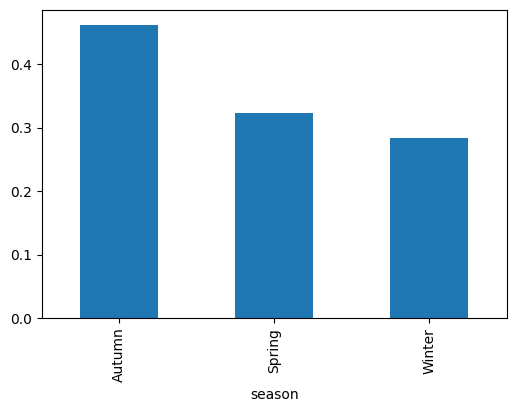

In [ ]:
df_filtrado.groupby("season")["is_occupied"].mean().plot(kind="bar", figsize=(6,4))

## Agrupación del número de eventos

Se crea una variable categórica `event_level` que agrupa el número de eventos en rangos (0, 1–5, 6–10, 11–20, más de 20). Esto permite analizar el efecto de diferentes niveles de eventos en la ocupación.

In [ ]:

df_filtrado["event_level"] = pd.cut(
    df_filtrado["num_events"],
    bins=[-1, 0, 5, 10, 20, 50],
    labels=["0", "1-5", "6-10", "11-20", "20+"]
)
df_filtrado.groupby("event_level")["is_occupied"].mean()

/tmp/ipykernel_27876/2913567764.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado["event_level"] = pd.cut(
/tmp/ipykernel_27876/2913567764.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtrado.groupby("event_level")["is_occupied"].mean()


,is_occupied
event_level,
0,0.358877
1-5,0.331718
6-10,0.299555
11-20,0.314768
20+,0.326168


## Agrupación de la asistencia total a eventos

Se discretiza la variable `total_attendance` en quintiles usando `qcut` para agrupar días según la asistencia a eventos y estudiar su relación con la ocupación.

In [ ]:
df_filtrado["attendance_level"] = pd.qcut(
    df_filtrado["total_attendance"],
    q=5,
    duplicates="drop"
)

df_filtrado.groupby("attendance_level")["is_occupied"].mean()

/tmp/ipykernel_27876/1893723708.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado["attendance_level"] = pd.qcut(
/tmp/ipykernel_27876/1893723708.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtrado.groupby("attendance_level")["is_occupied"].mean()


,is_occupied
attendance_level,
"(-0.001, 66565.0]",0.356054


## Distribución de asistencia total

Se muestra la frecuencia de los valores de `total_attendance` más comunes para entender la distribución de asistencia a eventos en el dataset.

In [ ]:
df_filtrado["total_attendance"].value_counts().head(10)

,count
total_attendance,
0,3525956
1423,16421
20000,16421
700,16421
2094,16421
6050,16421
10618,16421
1970,16421
40685,16421


## Influencia de la presencia de eventos en la ocupación

Se crea una variable binaria `has_event` que indica si hay asistencia total mayor a 0. Se agrupan los datos según `has_event` y se calcula la ocupación media para evaluar la influencia de la presencia de eventos.

In [ ]:
df_filtrado["has_event"] = (df_filtrado["total_attendance"] > 0).astype(int)
df_filtrado.groupby("has_event")["is_occupied"].mean()

/tmp/ipykernel_27876/3613228989.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado["has_event"] = (df_filtrado["total_attendance"] > 0).astype(int)


,is_occupied
has_event,
0,0.358877
1,0.320404


## Proporción de días con y sin eventos

Se calculan las proporciones de días con y sin eventos para comprender la prevalencia de cada caso en el conjunto de datos.

In [ ]:
# ¿Cuántos días con evento vs sin evento?
df_filtrado["has_event"].value_counts(normalize=True)

,proportion
has_event,
0,0.926636
1,0.073364


## Distribución de eventos por mes

Se contabiliza el número de observaciones con y sin eventos por mes y se presenta en formato tabla (`unstack`) para identificar meses con mayor o menor presencia de eventos.

In [ ]:
# ¿Eventos concentrados en ciertos meses?
df_filtrado.groupby(["month","has_event"])["is_occupied"].count().unstack()

has_event,0,1
month,,
1,426946,82105
2,459788,<NA>
3,509051,<NA>
4,295578,197052
9,323861,<NA>
10,509051,<NA>
11,492630,<NA>
12,509051,<NA>


## Efecto de los festivos en la ocupación

Se calcula la ocupación media según la variable `is_holiday` para explorar si los días festivos influyen en la ocupación.

In [ ]:
df_filtrado.groupby("is_holiday")["is_occupied"].mean()


,is_occupied
is_holiday,
0,0.357127
1,0.332892


## Impacto de la temperatura media

Se agrupan los datos en intervalos de temperatura media (`temp_mean`) y se calcula la ocupación media en cada rango, con el fin de detectar el efecto del clima sobre la ocupación.

In [ ]:
df_filtrado.groupby(pd.cut(df_filtrado["temp_mean"], bins=10))["is_occupied"].mean()

/tmp/ipykernel_27876/3875176168.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtrado.groupby(pd.cut(df_filtrado["temp_mean"], bins=10))["is_occupied"].mean()


,is_occupied
temp_mean,
"(3.579, 5.69]",0.286858
"(5.69, 7.78]",0.302644
"(7.78, 9.87]",0.289167
"(9.87, 11.96]",0.288087
"(11.96, 14.05]",0.306609
"(14.05, 16.14]",0.349057
"(16.14, 18.23]",0.424584
"(18.23, 20.32]",0.537386
"(20.32, 22.41]",0.494017


## Visualización de ocupación según temperatura

Se grafica la ocupación media por intervalos de temperatura para mostrar la tendencia observada en el análisis anterior.

/tmp/ipykernel_27876/3877184181.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtrado.groupby(


<Axes: xlabel='temp_mean'>

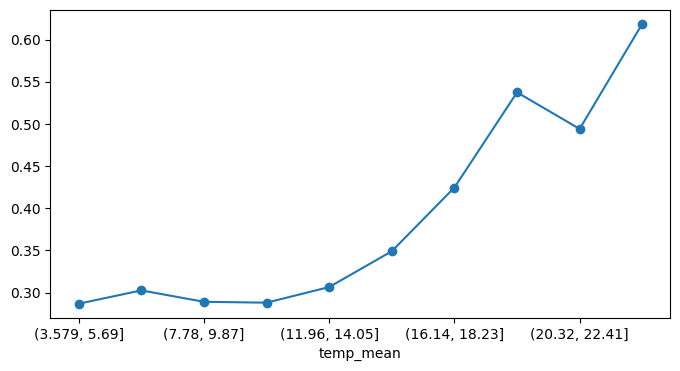

In [ ]:
df_filtrado.groupby(
    pd.cut(df_filtrado["temp_mean"], bins=10)
)["is_occupied"].mean().plot(marker="o", figsize=(8,4))

## Análisis de la precipitación

Se evalúa la relación entre la precipitación (`rain_mm`) agrupada en intervalos y la ocupación media, buscando patrones asociados a días lluviosos.

In [ ]:
df_filtrado.groupby(
    pd.cut(df_filtrado["rain_mm"], bins=10)
)["is_occupied"].mean()

/tmp/ipykernel_27876/1081682831.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtrado.groupby(


,is_occupied
rain_mm,
"(-0.0994, 9.94]",0.357026
"(9.94, 19.88]",0.360458
"(19.88, 29.82]",0.302379
"(29.82, 39.76]",0.351075
"(39.76, 49.7]",0.299677
"(49.7, 59.64]",<NA>
"(59.64, 69.58]",<NA>
"(69.58, 79.52]",<NA>
"(79.52, 89.46]",<NA>


## Interacción entre fin de semana y temperatura

Se calcula la ocupación media combinando la variable binaria `is_weekend` con intervalos de temperatura media. Esto permite ver cómo el efecto del fin de semana varía según el clima.

In [ ]:
df_filtrado.groupby(
    ["is_weekend", pd.cut(df_filtrado["temp_mean"], bins=5)]
)["is_occupied"].mean()

/tmp/ipykernel_27876/1619582379.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtrado.groupby(


is_weekend  temp_mean     
0           (3.579, 7.78]       0.3016
            (7.78, 11.96]      0.28548
            (11.96, 16.14]    0.323248
            (16.14, 20.32]    0.470699
            (20.32, 24.5]     0.545983
1           (3.579, 7.78]     0.290512
            (7.78, 11.96]     0.295933
            (11.96, 16.14]    0.310105
            (16.14, 20.32]    0.450288
            (20.32, 24.5]     0.587044
Name: is_occupied, dtype: Float64

## Ocupación según estación y fin de semana

Se calcula la ocupación media combinando la estación del año con la variable `is_weekend`, mostrando los resultados en una tabla (`unstack`).

In [ ]:
df_filtrado.groupby(["season", "is_weekend"])["is_occupied"].mean().unstack()

is_weekend,0,1
season,,
Autumn,0.46223,0.462388
Spring,0.322879,0.324334
Winter,0.282143,0.285203


## Selección de características para el modelo

Se define una lista de variables (`features`) que se utilizarán como entradas para entrenar el modelo de clasificación de ocupación.

In [21]:
features = [
    "temp_mean",
    "is_weekend",
    "month",
    "accommodates",
    "bedrooms",
    "beds",
    "number_of_reviews"
]

X = df_filtrado[features]
y = df_filtrado["is_occupied"]

X = X.fillna(0)

## Importación de bibliotecas para modelado

Se importan las funciones de `sklearn` necesarias para dividir los datos, entrenar un modelo de Random Forest y evaluar su desempeño.

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import sys

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Entrenamiento progresivo: warm_start añade árboles en cada iteración
model = RandomForestClassifier(
    n_estimators=10,  # empezamos con 10 árboles
    warm_start=True,
    random_state=42
)

step = 10        # árboles por paso
total = 100      # total de árboles

print(f"{'Árboles':>8} | {'Train Acc':>10} | {'Test Acc':>10}")
print("-" * 35)

for n in range(step, total + step, step):
    model.n_estimators = n
    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test,  model.predict(X_test))

    print(f"{n:>8} | {train_acc:>10.4f} | {test_acc:>10.4f}")
    sys.stdout.flush()

print("\n✅ Entrenamiento completado")
print(f"Train accuracy final: {train_acc:.4f}")
print(f"Test  accuracy final: {test_acc:.4f}")


 Árboles |  Train Acc |   Test Acc
-----------------------------------
      10 |     0.7924 |     0.6942
      10 |     0.7924 |     0.6942
      20 |     0.7955 |     0.6950
      20 |     0.7955 |     0.6950
      30 |     0.7963 |     0.6956
      30 |     0.7963 |     0.6956
      40 |     0.7967 |     0.6959
      40 |     0.7967 |     0.6959
      50 |     0.7968 |     0.6962
      50 |     0.7968 |     0.6962
      60 |     0.7969 |     0.6963
      60 |     0.7969 |     0.6963
      70 |     0.7969 |     0.6963
      70 |     0.7969 |     0.6963
      80 |     0.7969 |     0.6963
      80 |     0.7969 |     0.6963
      90 |     0.7969 |     0.6965
      90 |     0.7969 |     0.6965
     100 |     0.7970 |     0.6962

✅ Entrenamiento completado
Train accuracy final: 0.7970
Test  accuracy final: 0.6962
     100 |     0.7970 |     0.6962

✅ Entrenamiento completado
Train accuracy final: 0.7970
Test  accuracy final: 0.6962


## Inicialización de Vertex AI (opcional)

Se inicializa la plataforma Vertex AI de Google Cloud para entrenar y desplegar el modelo en la nube. Este paso es opcional y depende del entorno de trabajo.

In [ ]:
from google.cloud import aiplatform
aiplatform.init(
    project=PROJECT_ID,
    staging_bucket=BUCKET_URI,
    location=REGION,
    experiment=EXPERIMENT_NAME)

aiplatform.autolog()

## Cálculo de la importancia de características

Se calcula la importancia de cada variable en el modelo entrenado, lo que indica cuánto contribuye cada característica a la predicción de la ocupación.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values()

importances.plot(kind="barh", figsize=(8,5))
plt.title("Feature Importance")

## Visualización de la importancia de variables

Se crea un gráfico de barras para visualizar y comparar las importancias de las diferentes variables del modelo.

In [ ]:
importances.plot(kind="bar", figsize=(8,4))

## Incorporación de variables de retraso (lag)

Se ordenan los datos por `listing_id` y `date` y se crea la variable `lag_1` que representa si el alojamiento estaba ocupado en el día anterior. Esto permite capturar la dependencia temporal en la ocupación.

In [30]:
import numpy as np

df_filtrado = df_filtrado.sort_values(["listing_id", "date"])

df_filtrado["lag_1"] = df_filtrado.groupby("listing_id")["is_occupied"].shift(1)

df_filtrado["rolling_7"] = df_filtrado.groupby("listing_id")["is_occupied"]\
    .shift(1)\
    .rolling(7)\
    .mean()

df_filtrado["temp_weekend"] = df_filtrado["temp_mean"] * df_filtrado["is_weekend"]


df_filtrado["dow_sin"] = np.sin(2 * np.pi * df_filtrado["day_of_week"] / 7)
df_filtrado["dow_cos"] = np.cos(2 * np.pi * df_filtrado["day_of_week"] / 7)

df_filtrado["month_sin"] = np.sin(2 * np.pi * df_filtrado["month"] / 12)

## Actualización de características con la variable de lag

Se redefine la lista de variables incluidas en el modelo para incorporar la variable de retraso (`lag_1`) y se procede a entrenar un nuevo modelo con este conjunto de características.

In [ ]:
features = [
    "temp_mean",
    "is_weekend",
    "month",
    "lag_1",
    "rolling_7",
    "temp_weekend",
    "dow_sin",
    "dow_cos"
]

X = df_filtrado[features]
y = df_filtrado["is_occupied"]

## Entrenamiento y evaluación de un modelo de Random Forest

Se lleva a cabo el entrenamiento de un modelo de Random Forest sin fuga de información. Se divide el conjunto de datos de manera temporal, se calcula un baseline, y se ajustan incrementos de estimadores (`n_estimators`). Posteriormente, se presentan las métricas de precisión, balanced_accuracy y un informe de clasificación para evaluar el rendimiento del modelo.

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report
import pandas as pd
import sys

# -----------------------------
# 1. Preparar dataset
# -----------------------------
df_model = df_filtrado.copy()
df_model["date"] = pd.to_datetime(df_model["date"])
df_model = df_model.sort_values(["date", "listing_id"])

# -----------------------------
# 2. Features SIN leakage
# -----------------------------
features_clean = [
    "temp_mean",
    "is_weekend",
    "month",
    "day_of_week",
    "accommodates",
    "bedrooms",
    "beds",
    "minimum_nights",
    "number_of_reviews",
    "review_scores_rating",
    "review_scores_cleanliness",
    "review_scores_location",
    "review_scores_value",
    "latitude",
    "longitude"
]

X = df_model[features_clean].fillna(0)
y = df_model["is_occupied"]

# -----------------------------
# 3. Split temporal
# -----------------------------
split_date = df_model["date"].quantile(0.8)

train = df_model[df_model["date"] <= split_date]
test  = df_model[df_model["date"] > split_date]

X_train = train[features_clean].fillna(0)
y_train = train["is_occupied"]

X_test = test[features_clean].fillna(0)
y_test = test["is_occupied"]

print("Split date:", split_date)
print("Train:", train["date"].min(), "→", train["date"].max())
print("Test :", test["date"].min(), "→", test["date"].max())

# -----------------------------
# 4. Baseline
# -----------------------------
baseline_pred = [y_train.mode()[0]] * len(y_test)

print("\nBaseline accuracy:", accuracy_score(y_test, baseline_pred))
print("Baseline balanced accuracy:", balanced_accuracy_score(y_test, baseline_pred))

# -----------------------------
# 5. Entrenamiento progresivo
# -----------------------------
model = RandomForestClassifier(
    n_estimators=10,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=20,
    class_weight="balanced",
    warm_start=True,
    random_state=42,
    n_jobs=-1
)

step = 10
total = 50

print(f"\n{'Árboles':>8} | {'Train Acc':>10} | {'Test Acc':>10} | {'Bal Acc':>10}")
print("-" * 52)

for n in range(step, total + step, step):
    model.n_estimators = n
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    bal_acc = balanced_accuracy_score(y_test, test_pred)

    print(f"{n:>8} | {train_acc:>10.4f} | {test_acc:>10.4f} | {bal_acc:>10.4f}")
    sys.stdout.flush()

print("\n✅ Entrenamiento completado")
print(f"Train accuracy final: {train_acc:.4f}")
print(f"Test  accuracy final: {test_acc:.4f}")
print(f"Balanced accuracy final: {bal_acc:.4f}")

print("\nClassification report:")
print(classification_report(y_test, test_pred))

Split date: 2026-03-15 00:00:00
Train: 2025-09-01 00:00:00 → 2026-03-15 00:00:00
Test : 2026-03-16 00:00:00 → 2026-04-30 00:00:00

Baseline accuracy: 0.6688241196982655

Baseline accuracy: 0.6688241196982655
Baseline balanced accuracy: 0.5

 Árboles |  Train Acc |   Test Acc |    Bal Acc
----------------------------------------------------
Baseline balanced accuracy: 0.5

 Árboles |  Train Acc |   Test Acc |    Bal Acc
----------------------------------------------------


c:\Users\sescorue\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_forest.py:860: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributions. Pass the resulting weights as the class_weight parameter.
  warn(


      10 |     0.6933 |     0.6895 |     0.5996


c:\Users\sescorue\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_forest.py:860: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributions. Pass the resulting weights as the class_weight parameter.
  warn(


      20 |     0.6965 |     0.6886 |     0.6043


...

      30 |     0.6964 |     0.6834 |     0.6029


c:\Users\sescorue\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_forest.py:860: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributions. Pass the resulting weights as the class_weight parameter.
  warn(


      40 |     0.6981 |     0.6903 |     0.6088


c:\Users\sescorue\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_forest.py:860: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributions. Pass the resulting weights as the class_weight parameter.
  warn(


      50 |     0.6982 |     0.6891 |     0.6062

✅ Entrenamiento completado
Train accuracy final: 0.6982
Test  accuracy final: 0.6891
Balanced accuracy final: 0.6062

Classification report:

✅ Entrenamiento completado
Train accuracy final: 0.6982
Test  accuracy final: 0.6891
Balanced accuracy final: 0.6062

Classification report:
              precision    recall  f1-score   support

         0.0       0.73      0.85      0.79    505207
         1.0       0.55      0.36      0.43    250159

    accuracy                           0.69    755366
   macro avg       0.64      0.61      0.61    755366
weighted avg       0.67      0.69      0.67    755366

              precision    recall  f1-score   support

         0.0       0.73      0.85      0.79    505207
         1.0       0.55      0.36      0.43    250159

    accuracy                           0.69    755366
   macro avg       0.64      0.61      0.61    755366
weighted avg       0.67      0.69      0.67    755366

